<a href="https://colab.research.google.com/github/julianaruane/CRUD---PP2/blob/main/ProjAssistidoIV.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#Importação das bibliotecas
import os
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, optimizers, datasets
from matplotlib import pyplot as plt
import numpy as np


In [ ]:
(x_train_raw, y_train_raw), (x_test_raw, y_test_raw)=datasets.mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [ ]:
print(x_train_raw.shape, y_train_raw.shape)
print(x_test_raw.shape, y_test_raw.shape)
print(x_train_raw[0])
print(y_train_raw[0])

(60000, 28, 28) (60000,)
(10000, 28, 28) (10000,)
[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   3  18  18  18 126 136
  175  26 166 255 247 127   0   0   0   0]
 [  0   0   0   0   0   0   0   0  30  36  94 154 170 253 253 253 253 253
  225 172 253 242 195  64   0   0   0   0]
 [  0   0   0   0   0   0   0  49 238 253 253 253 253 253 253 253 253 251
   93  82  82  56  39   0   0   0   0   0]
 [  0   0   0 

In [ ]:
#Converte rotulos em variaveis
num_classes=10
y_train = keras.utils.to_categorical(y_train_raw, num_classes)
y_test = keras.utils.to_categorical(y_test_raw, num_classes)
print(y_train_raw[0])
print(y_train[0])

5
[0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]


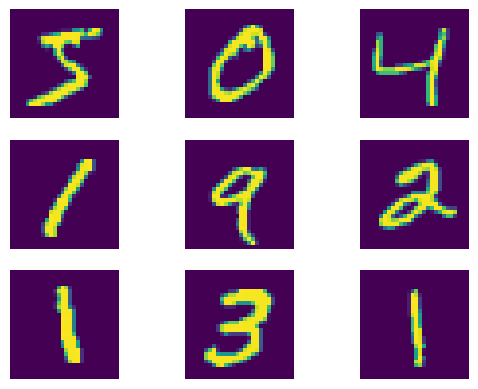

In [ ]:
plt.figure()
for i in range(9):
  plt.subplot(3,3,i+1)
  plt.imshow(x_train_raw[i])
  plt.axis('off')
plt.show()

In [ ]:
#conversao da matriz para um vetor sem perder informacao
x_train= x_train_raw.reshape(60000,784)
x_test= x_test_raw.reshape(10000,784)

In [ ]:
#normalizar vcalores dps pixels
x_train= x_train.astype('float32')/255
x_test= x_test.astype('float32')/255

In [ ]:
#Criar um modelo de rede neural profunda com tres camadas totalmente conectadas
model = keras.Sequential([
                         layers.Dense(512, activation='relu', input_dim=784),
                         layers.Dense(256, activation='relu'),
                         layers.Dense(128, activation='relu'),
                         layers.Dense(num_classes, activation='softmax')
])
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 567,434 (2.16 MB)

 Trainable params: 567,434 (2.16 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
Optimizer = optimizers.Adam(0.001)
model.compile(loss=keras.losses.categorical_crossentropy,
              optimizer=Optimizer,metrics=['accuracy'])

In [ ]:
#ajustando os dados de treinamento ao modelo e chamando o metodo fit para treinar
history = model.fit(x_train, y_train, batch_size=128,epochs=10, validation_data=(x_test, y_test), verbose=1)

Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.8717 - loss: 0.4290 - val_accuracy: 0.9644 - val_loss: 0.1083
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9748 - loss: 0.0863 - val_accuracy: 0.9749 - val_loss: 0.0794
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9830 - loss: 0.0534 - val_accuracy: 0.9749 - val_loss: 0.0804
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9866 - loss: 0.0392 - val_accuracy: 0.9786 - val_loss: 0.0685
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9913 - loss: 0.0281 - val_accuracy: 0.9807 - val_loss: 0.0675
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9932 - loss: 0.0199 - val_accuracy: 0.9801 - val_loss: 0.0767
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9940 - loss: 0.0190 - val_accuracy: 0.9762 - val_loss: 0.0806
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9938 - loss: 0.0181 - val_accuracy: 0.

In [ ]:
#avaliando modelo DNN
score = model.evaluate(x_test, y_test, verbose=0)
print('perda do teste: ', score[0])
print('Acurácia do teste: ', score[1])

perda do teste:  0.10219620168209076
Acurácia do teste:  0.9758999943733215


In [ ]:
# criar pasta do modelo no caminho relativo
model.save('./model/final_DNN_model.h5')

In [ ]:
from tensorflow.keras.models import load_model
new_model = load_model('./model/final_DNN_model.h5')
new_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 567,436 (2.16 MB)

 Trainable params: 567,434 (2.16 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

In [ ]:
new_score = new_model.evaluate(x_test,y_test, verbose=0)
print('perda do teste: ', new_score[0])
print('Acurácia do teste: ', new_score[1])

perda do teste:  0.10219620168209076
Acurácia do teste:  0.9758999943733215


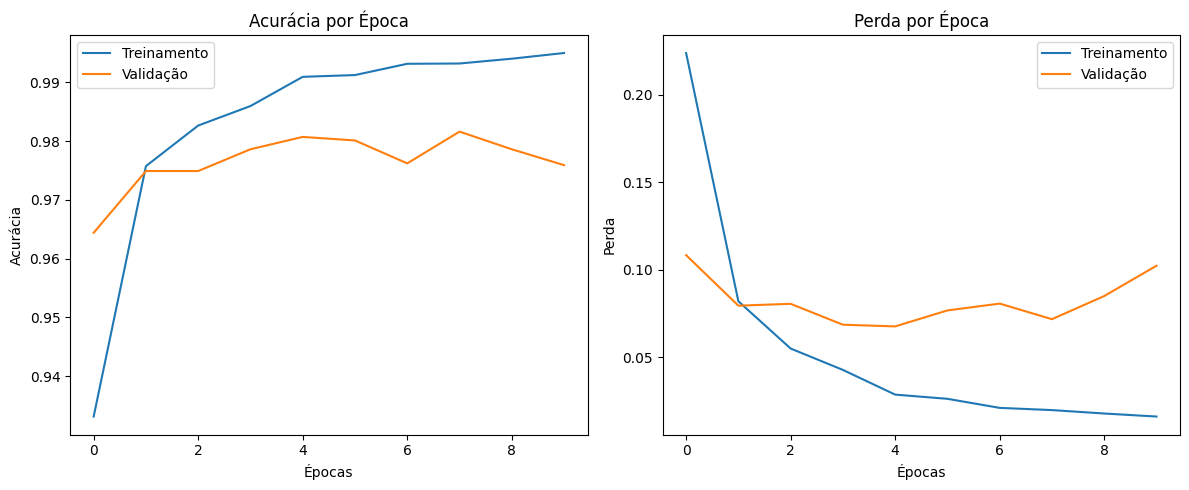

In [ ]:
#mostrar grafico do hitsorico de acuaria do modelo entre as epocas e o grafico de perdas
#plotar a acurácia
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Treinamento')
plt.plot(history.history['val_accuracy'], label='Validação')
plt.title('Acurácia por Época')
plt.xlabel('Épocas')
plt.ylabel('Acurácia')
plt.legend()

#pltar a perda

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Treinamento')
plt.plot(history.history['val_loss'], label='Validação')
plt.title('Perda por Época')
plt.xlabel('Épocas')
plt.ylabel('Perda')
plt.legend()
plt.tight_layout()
plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


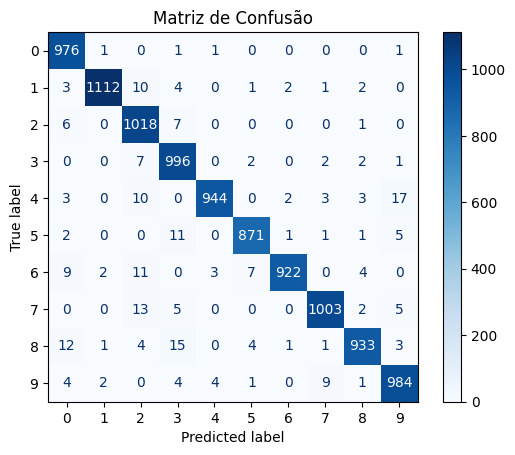

In [ ]:
# Gerar predict e avaliar com matriz de confusão
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Obter previsoes do modelo
y_pred_prob = model.predict(x_test) # Retorna probbnabilidades

# Converter para rotulos preditos
y_pred = np.argmax(y_pred_prob, axis=1)

# Convertr rotulos reeis (se estiverem one-hot encoded)
y_true = np.argmax(y_test, axis= 1)

# Gerar matriz de confusão
cm = confusion_matrix(y_true, y_pred)

# Exibir a matriz de confusão com rótulos
disp = ConfusionMatrixDisplay (confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.title('Matriz de Confusão')
plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Acurácia: (acc:.4f)
Precisão (macro): (prec:.4f)
Recall (macro): (rec:.4f)
F1-score (macro): (f1:.4f)
Cohen Kappa: (kappa:.4f)

Relatório de Classificação:

              precision    recall  f1-score   support

           0       0.96      1.00      0.98       980
           1       0.99      0.98      0.99      1135
           2       0.95      0.99      0.97      1032
           3       0.95      0.99      0.97      1010
           4       0.99      0.96      0.98       982
           5       0.98      0.98      0.98       892
           6       0.99      0.96      0.98       958
           7       0.98      0.98      0.98      1028
           8       0.98      0.96      0.97       974
           9       0.97      0.98      0.97      1009

    accuracy                           0.98     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       0.98      0.98      0.98     10000



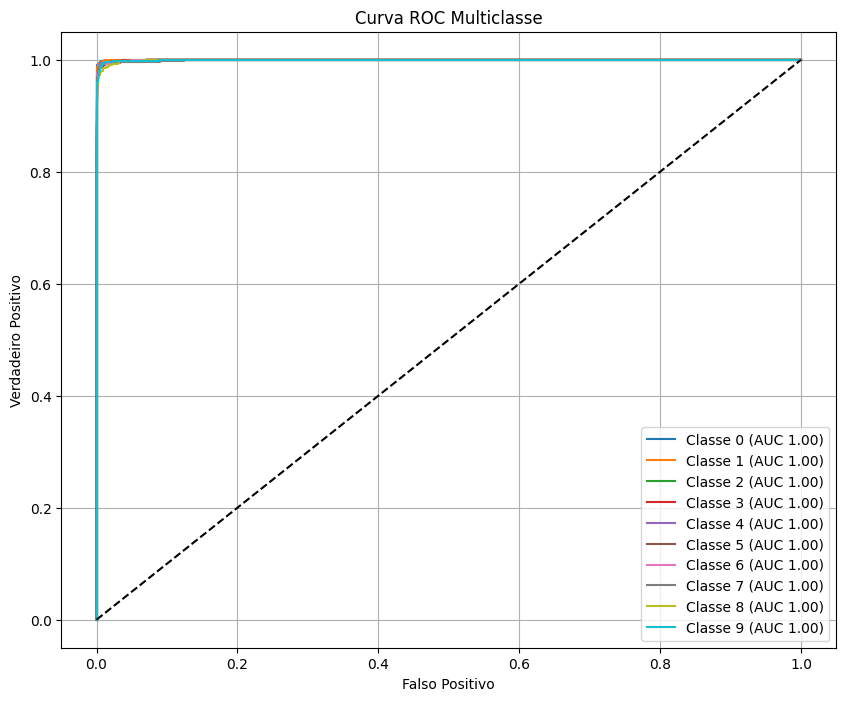

In [ ]:
# Gerar acurácia, precisão, cobertura, F1, Cohen Kappa, PRF e ROC
y_pred_prob =model.predict(x_test)

#Probabilidades
y_pred =np.argmax(y_pred_prob, axis=1)

#Rotulos previstos
y_true= np.argmax(y_test, axis=1)

from sklearn.metrics import (accuracy_score, precision_score, recall_score,
f1_score, cohen_kappa_score, classification_report, roc_curve, auc, roc_auc_score)

import matplotlib.pyplot as plt
from sklearn.preprocessing import label_binarize

# Acurácia
acc =accuracy_score(y_true, y_pred)
print (f"Acurácia: (acc:.4f)")

# Precisão, Recall e F1 (macro média das classes)
prec= precision_score(y_true, y_pred, average='macro')
rec= recall_score(y_true, y_pred, average='macro')
f1= f1_score(y_true, y_pred, average='macro')
print (f"Precisão (macro): (prec:.4f)")
print (f"Recall (macro): (rec:.4f)")
print (f"F1-score (macro): (f1:.4f)")

# Cohen Kappa

kappa =cohen_kappa_score(y_true, y_pred)

print(f"Cohen Kappa: (kappa:.4f)")

# Relatório completo (PRF por classe)
print("\nRelatório de Classificação:\n")
print(classification_report (y_true, y_pred))


# Binarizar os rótulos para ROC multiclasse.
n_classes =y_pred_prob.shape[1]
y_true_bin= label_binarize(y_true, classes=range (n_classes))

# Calcular ROC e AUC para cada classe
fpr =dict()
tpr =dict()
roc_auc =dict()
for i in range(n_classes):
  fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_pred_prob[:, i])
  roc_auc[i] = auc(fpr[i], tpr[i])

# Plotar curvas ROC
plt.figure(figsize=(10, 8))
for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], label=f"Classe {i} (AUC {roc_auc[i]:.2f})")

plt.plot([0, 1], [0, 1], 'k--') # linha de referência
plt.xlabel('Falso Positivo')
plt.ylabel('Verdadeiro Positivo')
plt.title('Curva ROC Multiclasse')
plt.legend(loc='lower right')
plt.grid()
plt.show()

In [ ]:
#criar um modelo de rede neural convolucional (CNN)
model = keras.Sequential()

#camada de entrada.
model.add(keras.layers.Conv2D (filters=32, kernel_size=5, strides=(1,1),padding='same',activation=tf.nn.relu, input_shape=(28,28,1))
)

model.add(keras.layers.MaxPool2D(pool_size=(2,2),strides=(2,2),padding='valid'))

#segunda camada convolucional
model.add(keras.layers.Conv2D(filters=64,kernel_size=3,strides=(1,1),padding='same',activation=tf.nn.relu))

model.add(keras.layers.MaxPool2D(pool_size=(2,2), strides=(2,2),padding='valid'))

#adicionar camada de dropout para tentar evitar overfitting.
model.add(keras.layers.Dropout (0.25))
model.add(keras.layers.Flatten())

#camada totalmente conectada
model.add(keras.layers.Dense(units=128, activation=tf.nn.relu))
model.add(keras.layers.Dropout(0.5))

#camada de saída
model.add(keras.layers.Dense(units=10, activation=tf.nn.softmax))
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       401,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 422,154 (1.61 MB)

 Trainable params: 422,154 (1.61 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
%%time
#expansão das dimensoes para os patamares originais
X_train = x_train.reshape (60000, 28,28,1)
X_test = x_test.reshape (10000, 28, 28,1)
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.fit(x=X_train, y=y_train, epochs=5, validation_data=(X_test, y_test), batch_size=128)

Epoch 1/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 22s 22ms/step - accuracy: 0.8120 - loss: 0.5916 - val_accuracy: 0.9812 - val_loss: 0.0589
Epoch 2/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9688 - loss: 0.1022 - val_accuracy: 0.9869 - val_loss: 0.0371
Epoch 3/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9780 - loss: 0.0735 - val_accuracy: 0.9891 - val_loss: 0.0325
Epoch 4/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9833 - loss: 0.0569 - val_accuracy: 0.9908 - val_loss: 0.0289
Epoch 5/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9847 - loss: 0.0514 - val_accuracy: 0.9924 - val_loss: 0.0238
CPU times: user 20.7 s, sys: 1.55 s, total: 22.3 s
Wall time: 33.6 s


In [ ]:
test_loss, test_acc=model.evaluate(x=X_test,y=y_test)
print("Acurácia do teste da CNN: %.2f"%test_acc)
print("Perda do teste da CNN: %.2f"%test_loss)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9904 - loss: 0.0282
Acurácia do teste da CNN: 0.99
Perda do teste da CNN: 0.02


In [ ]:
model.save('./model/final_CNN_model.h5')
#model.save('./model/final_CNN_model.keras')
#keras.saving.save_model (model, 'final_CNN_model.keras')

In [ ]:
from tensorflow.keras.models import load_model
from tensorflow.keras.activations import softmax

# Define custom_objects to map the problematic identifier to the correct function
custom_objects = {'softmax_v2': softmax}
new_model = load_model('./model/final_CNN_model.h5', custom_objects=custom_objects)
new_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       401,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 422,156 (1.61 MB)

 Trainable params: 422,154 (1.61 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

In [ ]:
1 #from tensorflow.keras.models import load_model
2 #new_model = load_model('./model/final_CNN_model.h5')
3 #new_model.summary()

3

primeiras 20 primeiras imagens do conjunto de teste
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 596ms/step
resultados da PREVISÃO das 20 primeiras imagens do conjunto de teste
7,2,1,0,4,	
1,4,9,5,9,	
0,6,9,0,1,	
5,9,7,3,4,	
9,6,6,5,4,	
0,7,4,0,1,	


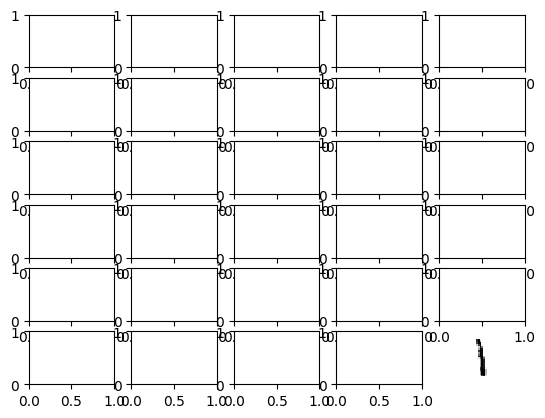

In [ ]:
#visualize os resultados da saíde do conjunto de testes
%matplotlib inline
def res_visual(n):

  #faça predição no conjunto de testes usando new_model
  final_opt_a=np.argmax(model.predict(X_test [0:n]), axis=-1)

  #print(final_opt_a)
  fig, ax =plt.subplots (nrows=int(n/5), ncols=5)
  ax =ax.flatten()
  print('resultados da PREVISÃO das 20 primeiras imagens do conjunto de teste')
  for i in range(n):
    print(final_opt_a[i], end=',')
    if int((i+1)%5) == 0:
      print('\t')

  #vendo as imagens do banco
  img = X_test[i].reshape((28,28))
  plt.axis("off")
  ax[i].imshow(img, cmap='Greys', interpolation='nearest')
  ax[i].axis("off")
print('primeiras 20 primeiras imagens do conjunto de teste')
res_visual(30)

***----------------------------------------------STREAMLIT----------------------------------------------***

In [ ]:
from google.colab import files
uploaded = files.upload()


In [ ]:
from tensorflow.keras.models import load_model
model = load_model('model/final_CNN_model.h5')

In [ ]:

!pip install streamlit pyngrok tensorflow pillow numpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 58.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 39.2 MB/s eta 0:00:00


In [ ]:
%%writefile app.py

import streamlit as st
import tensorflow as tf
from tensorflow.keras.preprocessing import image
import numpy as np
from PIL import Image


def softmax_v2(x):
    return tf.nn.softmax(x)

tf.keras.utils.get_custom_objects()["softmax_v2"] = softmax_v2

st.set_page_config(page_title="Numero", layout="centered")
st.title("IA para Diagnóstico de Número")
st.write("Envie uma imagem e veja a previsão.")


classes = [str(i) for i in range(10)]


@st.cache_resource
def carregar_modelo():
    model = tf.keras.models.load_model(
        "final_CNN_model.h5",
        compile=False
    )
    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

model = carregar_modelo()


uploaded_file = st.file_uploader("Escolha uma imagem", type=["jpg", "jpeg", "png"])

if uploaded_file is not None:
    img = Image.open(uploaded_file)
    st.image(img, caption="Imagem enviada", use_column_width=True)


    img = img.convert("L")


    img = img.resize((28, 28))
    img_array = np.array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=-1)
    img_array = np.expand_dims(img_array, axis=0)

    if st.button("Analisar"):
        pred = model.predict(img_array)[0]
        idx = np.argmax(pred)

        resultado = classes[idx]
        confianca = round(float(pred[idx]) * 100, 2)

        st.success(f"Diagnóstico: {resultado}")
        st.info(f"Confiança: {confianca}%")

        st.write("### Probabilidades:")
        for c, p in zip(classes, pred):
            st.write(f"{c}: {round(float(p)*100, 2)}%")


Overwriting app.py


In [ ]:
!pip install pyngrok

In [ ]:
!kill $(lsof -t -i:8501) 2>/dev/null

In [ ]:
from pyngrok import ngrok
ngrok.kill()

In [ ]:
!streamlit run app.py --server.address=0.0.0.0 --server.port=8501



2025-11-18 22:32:07.084 Port 8502 is already in use


In [ ]:

from pyngrok import ngrok

ngrok.kill()
ngrok.set_auth_token("35fcmVmp7VNXFP6BWmciTg1GzZw_6GxjTbdpGK5cShPzA9Yni")

public_url = ngrok.connect(8502)
print("🔗 Link público:", public_url)

!nohup streamlit run app.py --server.port 8501 --server.headless true &>/dev/null &

!kill $(lsof -t -i:8501) 2>/dev/null

!nohup streamlit run app.py --server.port 8501 --server.headless true &>/dev/null &


🔗 Link público: NgrokTunnel: "https://jenifer-untopping-foppishly.ngrok-free.dev" -> "http://localhost:8502"
